In [73]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [74]:
path = '../../dataset/preprocessed/hotel_bookings_dummy.csv'
df = pd.read_csv(path)

먼저 엘보우 그래프를 봐서 몇개의 군집이 적당한지 체크

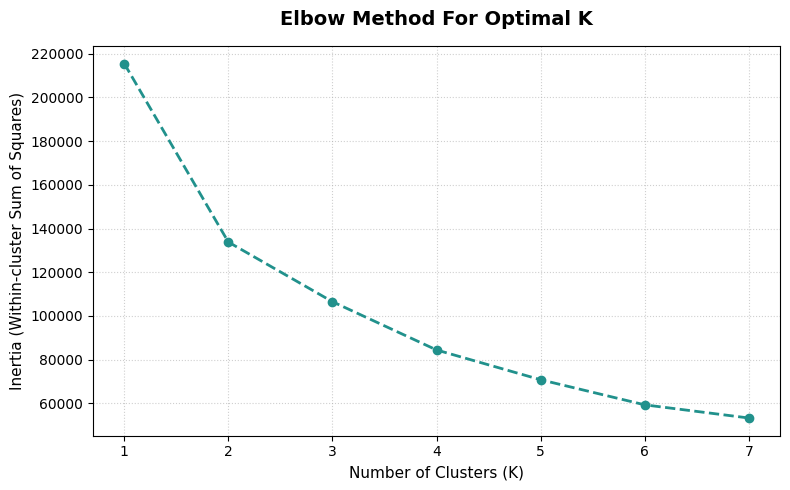

In [ ]:
# 취소한 사람들만 필터링
df_canceled = df[df["is_canceled"] == 1].copy()

lead_time_cutoff = df_canceled["lead_time"].quantile(0.99)
adr_cutoff = df_canceled["adr"].quantile(0.99)

df_canceled = df_canceled[
    (df_canceled["lead_time"] <= lead_time_cutoff)
    & (df_canceled["adr"] <= adr_cutoff)
    & (df_canceled["adr"] > 0)
]

# 상위 5개의 임포턴스 컬럼만
top_5_features = [
    "deposit_type_Non Refund",
    "lead_time",
    "adr",
    "total_of_special_requests",
    "market_segment_Online TA",
]
X_clustering = df_canceled[top_5_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)



inertia_list = []
k_range = range(1, 8)  # 군집 개수를 1개부터 7개까지 테스트

for k in k_range:
    
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init="auto", random_state=42)
    kmeans.fit(X_scaled)
    inertia_list.append(kmeans.inertia_)  # 시각화를 위한 군집 내 응집도를 나타내는 점수 저장



# 엘보우 차트 그리기

plt.clf()
plt.close("all")

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_list, marker="o", linestyle="--", color="#21918c", linewidth=2)


plt.title("Elbow Method For Optimal K", fontsize=14, weight="bold", pad=15)
plt.xlabel("Number of Clusters (K)", fontsize=11)
plt.ylabel("Inertia (Within-cluster Sum of Squares)", fontsize=11)
plt.xticks(k_range)
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

그래프가 2에서 꺾이긴 하지만 2개론 충분한 결과를 도출하기 어려워서 3개의 군집으로 결정

5개 변수 군집
                  deposit_type_Non Refund  lead_time     adr  \
canceled_cluster                                               
0                                    0.88     223.90   86.50   
1                                    0.00      92.03  113.37   
2                                    0.00     108.45  119.77   

                  total_of_special_requests  market_segment_Online TA  
canceled_cluster                                                       
0                                      0.00                      0.00  
1                                      0.01                      0.65  
2                                      1.37                      0.90  


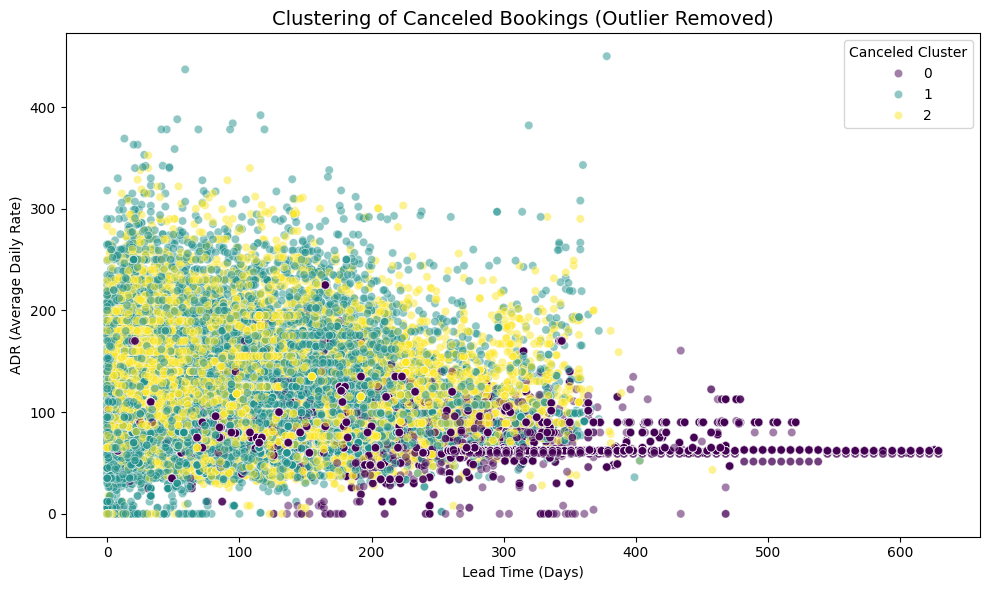

In [77]:
# 취소 고객들만 필터링
df_canceled = df[df["is_canceled"] == 1].copy()

# 아웃라이너가 존재하여 kmeans 군집화가 이상하게 나오므로 아웃라이너 제외
df_canceled = df_canceled[df_canceled["adr"] < 500]

# 피처 임포턴스 상위 5개 변수 추출
top_5_features = [
    "deposit_type_Non Refund",
    "lead_time",
    "adr",
    "total_of_special_requests",
    "market_segment_Online TA",
]

X_clustering = df_canceled[top_5_features].copy()

# 스케일링
scaler = StandardScaler()
scaler.fit(X_clustering) 
X_scaled = scaler.transform(X_clustering)  


kmeans = KMeans(n_clusters=3, init="k-means++", random_state=42)
kmeans.fit(X_scaled)  

df_canceled["canceled_cluster"] = kmeans.labels_


print("5개 변수 군집")
cluster_summary = df_canceled.groupby("canceled_cluster")[top_5_features].mean()
print(cluster_summary.round(2))


plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="lead_time",
    y="adr",
    hue="canceled_cluster",
    data=df_canceled,
    palette="viridis",
    alpha=0.5,
)
plt.title("Clustering of Canceled Bookings (Outlier Removed)", fontsize=14)
plt.xlabel("Lead Time (Days)")
plt.ylabel("ADR (Average Daily Rate)")
plt.legend(title="Canceled Cluster")
plt.tight_layout()
plt.show()

데이터 특성상 2차원은 가시성이 안좋아 3차원으로 나타내기로 결정

맨 하단에 ax.view_init(elev=10, azim=-120) 수치를 바꿔주면 각도가 바뀜

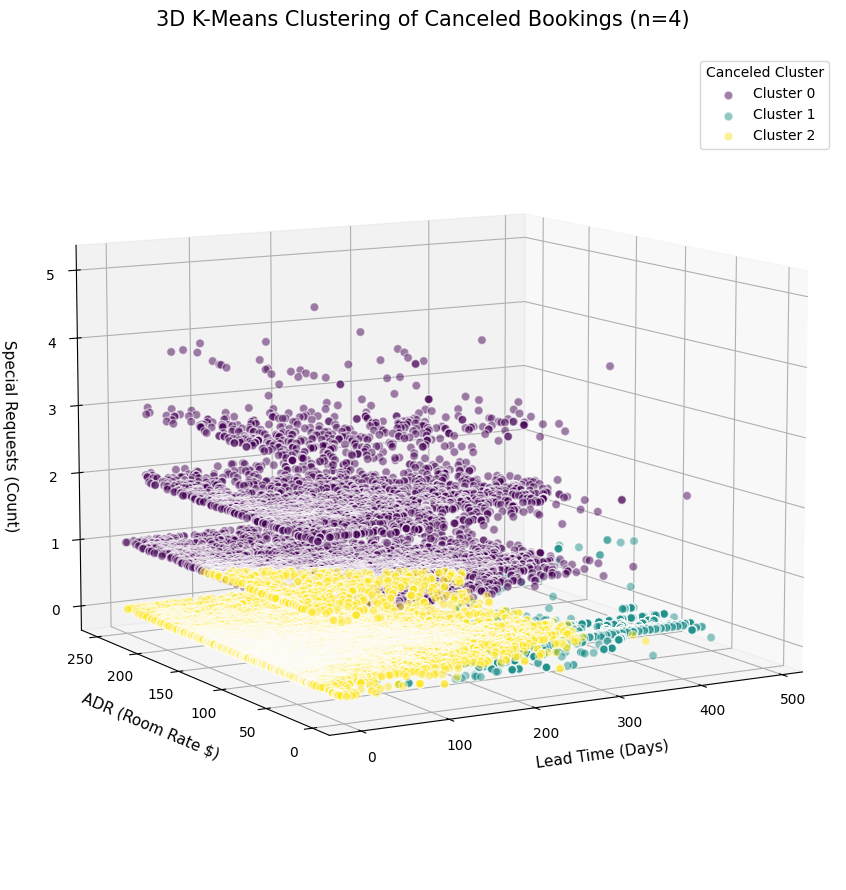

In [ ]:
df_canceled = df[df["is_canceled"] == 1].copy()

lead_time_cutoff = df_canceled["lead_time"].quantile(0.99) # 1%의 아웃라이너 제외
adr_cutoff = df_canceled["adr"].quantile(0.99)

df_canceled = df_canceled[
    (df_canceled["lead_time"] <= lead_time_cutoff)
    & (df_canceled["adr"] <= adr_cutoff)
    & (df_canceled["adr"] > 0)
]

# 5개 상위 컬럼 지정
top_5_features = [
    "deposit_type_Non Refund",
    "lead_time",
    "adr",
    "total_of_special_requests",
    "market_segment_Online TA",
]
X_clustering = df_canceled[top_5_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)


kmeans = KMeans(n_clusters=3, init="k-means++", random_state=42)
df_canceled["canceled_cluster"] = kmeans.fit_predict(X_scaled)



plt.clf()
plt.close("all")

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")


colors = ["#440154", "#21918c", "#fde725"]


for cluster_id in sorted(df_canceled["canceled_cluster"].unique()):
    cluster_data = df_canceled[df_canceled["canceled_cluster"] == cluster_id]

    ax.scatter(
        cluster_data["lead_time"],  # X축
        cluster_data["adr"],  # Y축
        cluster_data["total_of_special_requests"],  # Z축
        label=f"Cluster {cluster_id}",
        c=colors[cluster_id], 
        alpha=0.5,
        edgecolors="w",
        s=40,
    )

# 축 이름 및 타이틀 설정
ax.set_title("3D K-Means Clustering of Canceled Bookings (n=4)", fontsize=15, pad=20)
ax.set_xlabel("Lead Time (Days)", fontsize=11, labelpad=10)
ax.set_ylabel("ADR (Room Rate $)", fontsize=11, labelpad=10)
ax.set_zlabel("Special Requests (Count)", fontsize=11, labelpad=10)

ax.legend(title="Canceled Cluster", fontsize=10)
ax.view_init(elev=10, azim=-120)

plt.tight_layout()
plt.show()

보라색 = 특별 요청횟수의 군집단이며 요청횟수가 적을수록 취소확률이 높아짐


노란색 = 여행사에서 대거 취소했을 가능성이 높은 집단


민트색 = 방값에 영향을 많이 받는 집단